<a href="https://colab.research.google.com/github/evgeny-kolonsky/Lab4/blob/main/PE/RCA929/Lab4_PE_RCA929.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Photoelectric effect

v0.2.1 Automated measurements. Diodes

v0.2.2 Lamp + Filters

v0.3.0 Du Bridges method extracting V0

v0.3.1 Resume added

v0.3.2 90CV tube

v0.4.0 anode+dark current as baseline, not dark current as it was before

v.0.5.0 RCA929 tube

v.0.5.1 find_root logic changed: V0 is fitted by linear part, thus lowering effective V0

v0.5.2 Offset rethinked (Melissons, Experiments in modern physics, Photoelectric experiment) - it is *anode* work prtential $\phi_A$, which is not table value

# Resume



## Контактная разность потенциалов: что даёт наклон, а что — оффсет

Фотоэлектрон стартует с уровня Ферми катода и поглощает фотон $h\nu$, так что его **полная** энергия относительно уровня Ферми катода становится $E_{F,C} + h\nu$ — независимо от работы выхода катода $\varphi_C$. Работа выхода катода задаёт лишь кинетическую энергию электрона снаружи катода ($h\nu - \varphi_C$), но не его полную энергию.

При запирающем напряжении $V_s$ уровень Ферми анода поднят на $eV_s$, а вакуумный уровень у анода лежит на $\varphi_A$ выше:

$$E_{\text{вак},A} = E_{F,C} + eV_s + \varphi_A.$$

Условие остановки самых энергичных электронов — равенство их полной энергии этому барьеру:

$$E_{F,C} + h\nu = E_{F,C} + eV_s + \varphi_A
\quad\Longrightarrow\quad
eV_s = h\nu - \varphi_A.$$

Работа выхода катода $\varphi_C$ **сокращается полностью**: контактная разность потенциалов подменяет её работой выхода анода. Отсюда

$$V_s(\nu) = \frac{h}{e}\,\nu - \frac{\varphi_A}{e}.$$

### Практические следствия

- **Наклон** прямой $V_s(\nu)$ равен $h/e$ — это чистая референсная величина, к ней эксперимент привязывается напрямую.
- **Оффсет** (точка пересечения) равен работе выхода **анода** $\varphi_A$, то есть коллектора, а **не** фотокатода. Катод в оффсет не входит вообще; оффсет не лежит «между $\varphi_A$ и $\varphi_C$».
- Точное референсное значение $\varphi_A$ **неизвестно**: анод цезирован при изготовлении лампы, и его эффективная работа выхода индивидуальна для каждого экземпляра. Поэтому оффсет используется как извлекаемый параметр, а не как проверка против табличного значения.
- Извлекаемый из фита оффсет дополнительно смещён артефактами метода (полоса LED, остаточный обратный ток, кривизна ВАХ, а для катода S-1 — многоканальный порог), поэтому равен $\varphi_A$ лишь приближённо.

> **Вывод.** Эксперимент Милликена позволяет чисто измерить $h/e$ (по наклону), но **принципиально не позволяет** измерить работу выхода фотокатода — она сокращается контактной разностью потенциалов. Из оффсета определяется работа выхода анода-коллектора, а не катода.

In [1]:
import numpy as np
import requests
import matplotlib.pyplot as plt
from scipy.stats import linregress
from scipy.optimize import curve_fit
from scipy.interpolate import interp1d
from scipy.constants import h, elementary_charge as e, speed_of_light as c
from urllib import request

In [2]:
def wavelength_to_color(wavelength, gamma=0.8):
    ''' taken from http://www.noah.org/wiki/Wavelength_to_RGB_in_Python
    This converts a given wavelength of light to an
    approximate RGB color value. The wavelength must be given
    in nanometers in the range from 380 nm through 750 nm
    (789 THz through 400 THz).

    Based on code by Dan Bruton
    http://www.physics.sfasu.edu/astro/color/spectra.html
    '''
    wavelength = float(wavelength)
    if wavelength < 380:
        wavelength = 380.
    if wavelength > 750:
        wavelength = 750.
    if 380 <= wavelength <= 440:
        attenuation = 0.3 + 0.7 * (wavelength - 380) / (440 - 380)
        R = ((-(wavelength - 440) / (440 - 380)) * attenuation) ** gamma
        G = 0.0
        B = (1.0 * attenuation) ** gamma
    elif 440 <= wavelength <= 490:
        R = 0.0
        G = ((wavelength - 440) / (490 - 440)) ** gamma
        B = 1.0
    elif 490 <= wavelength <= 510:
        R = 0.0
        G = 1.0
        B = (-(wavelength - 510) / (510 - 490)) ** gamma
    elif 510 <= wavelength <= 580:
        R = ((wavelength - 510) / (580 - 510)) ** gamma
        G = 1.0
        B = 0.0
    elif 580 <= wavelength <= 645:
        R = 1.0
        G = (-(wavelength - 645) / (645 - 580)) ** gamma
        B = 0.0
    elif 645 <= wavelength <= 750:
        attenuation = 0.3 + 0.7 * (750 - wavelength) / (750 - 645)
        R = (1.0 * attenuation) ** gamma
        G = 0.0
        B = 0.0
    else:
        R = 0.0
        G = 0.0
        B = 0.0
    r = int(R*255)
    g = int(G*255)
    b = int(B*255)
    return "#{:02x}{:02x}{:02x}".format(r, g, b)

#Volt-ampere curve


# Dark and Anode current

In [3]:
URL = 'https://raw.githubusercontent.com/evgeny-kolonsky/Lab4/refs/heads/main/PE/RCA929/'
NORMPOINT = 0 #V
ANODE_VMAX = -1.5 #V


import numpy as np
from scipy.stats import linregress


def find_root2(V, I, *,
              noise_k=20.0,
              r2_min=0.999,
              min_points=5,
              trim_right=0,
              return_diagnostics=False):
    """
    Stopping voltage V0 by the Du Bridge method, fitting the LINEAR segment
    of sqrt(cathode current) and extrapolating to zero.

    Strategy (grows the window from V=0 leftward):
      1. baseline = anode + dark + leakage, fitted where cathode is off
         (V <= anode_Vmax) and subtracted -> R = cathode current.
      2. On the retarding side (V<0, cathode on), walk from the point
         nearest V=0 toward more negative V, adding points one at a time.
         Keep the LONGEST window whose linear fit of sqrt(R) vs V still has
         R^2 >= r2_min. This stops automatically when the thermal foot
         (left bend) starts to spoil the straight line.
      3. Optionally drop `trim_right` points nearest V=0 first, to discard
         the saturation / space-charge bend at the right end.
      4. V0 = x-intercept of that linear segment (foot is never used).

    No spectrum and no Fowler-DuBridge model required -- one rule:
    "fit the line where it is straight, extrapolate to zero."

    Parameters
    ----------
    noise_k    : cathode counts as "on" when R > noise_k * baseline scatter.
    r2_min     : linearity threshold for growing the window.
    min_points : smallest acceptable linear segment.
    trim_right : how many points nearest V=0 to skip (saturation bend).
    """
    V = np.asarray(V, float); I = np.asarray(I, float)
    order = np.argsort(V); V, I = V[order], I[order]

    base = V <= ANODE_VMAX
    if base.sum() < 3:
        return (np.nan, {"reason": "no baseline region; extend sweep"}) \
            if return_diagnostics else np.nan
    lr = linregress(V[base], I[base])
    R = I - (lr.slope * V + lr.intercept)
    noise = np.std(R[base])

    on = (R > noise_k * noise) & (V < NORMPOINT) & (V > ANODE_VMAX)
    if on.sum() < min_points + trim_right:
        return (np.nan, {"reason": "too few cathode points", "baseline": lr}) \
            if return_diagnostics else np.nan

    xv = V[on]; yv = np.sqrt(R[on])
    # sort from V=0 (right) toward negative (left)
    idx = np.argsort(xv)[::-1]
    xs, ys = xv[idx], yv[idx]
    if trim_right:
        xs, ys = xs[trim_right:], ys[trim_right:]

    # grow window from the right; keep the longest with R^2 >= r2_min
    best_n, best_fit = 0, None
    for n in range(min_points, len(xs) + 1):
        f = linregress(xs[:n], ys[:n])
        if f.rvalue**2 >= r2_min:
            best_n, best_fit = n, f
        # once it has been good and then drops, we can stop early
        elif best_n >= min_points and f.rvalue**2 < r2_min:
            break
    if best_fit is None:                       # never linear enough -> longest run
        best_n = len(xs); best_fit = linregress(xs, ys)

    V0 = -best_fit.intercept / best_fit.slope
    if return_diagnostics:
        seg = idx[trim_right: trim_right + best_n]
        return V0, {"anode_fit": lr, "noise": noise, "cathode_current": R,
                    "cathode_mask": on, "fit_x": xs[:best_n], "fit_y": ys[:best_n],
                    "cathode_fit": best_fit, "r2": best_fit.rvalue**2, "best_n": best_n,
                    "xv": xv, "yv":yv}
    return V0


def v0_sensitivity(V, I, r2_list=(0.995, 0.999, 0.9995),
                   trim_list=(0, 2, 4), **kw):
    """Spread of V0 over linearity threshold AND right-trim = honest systematic."""
    vals = []
    for r2 in r2_list:
        for tr in trim_list:
            v = find_root2(V, I, r2_min=r2, trim_right=tr, **kw)
            if np.isfinite(v):
                vals.append(v)
    if not vals:
        return np.nan, np.nan
    return float(np.mean(vals)), float(np.ptp(vals))


(0.0, 0.0001529309150635238)

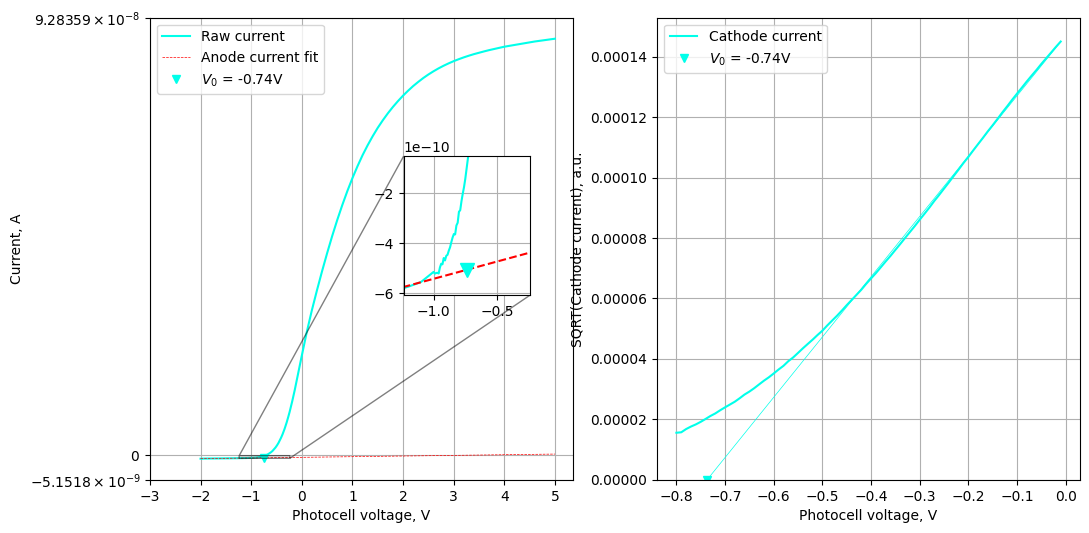

In [4]:
# example
fig, ax = plt.subplots(1, 2, figsize=(12,6))
ax0, ax1 = ax[0], ax[1]
names = ['yellow_RCA929', 'green_RCA929', 'violet_RCA929']
waves = [592, 525, 397]
name, wl = 'blue_RCA929', 492

color = wavelength_to_color(wl)
url = URL+ f'{name}.csv'
text = request.urlopen(url).read().decode('utf-8').splitlines()
LED_V,V_set,V_actual,I_avg_A, I_std_A,  = np.genfromtxt(text, \
                              delimiter=',', usecols=[0,1,2,3,4], skip_header=1, unpack=True)
powers = np.unique(LED_V)
V = V_set[LED_V==powers[0]]
I = I_avg_A[LED_V==powers[0]]
V0, debug = find_root2(V, I, return_diagnostics=True)
anode_fit = debug['anode_fit']
ax0.plot(V, I, color=color, label='Raw current')
ax0.plot(V, anode_fit.slope * V + anode_fit.intercept, color='red', lw=0.5, ls='--', label='Anode current fit')
ax0.plot(V0, anode_fit.slope * V0 + anode_fit.intercept, 'v', color=color, label=rf'$V_0$ = {V0:.2f}V')
ax0.set_xlabel('Photocell voltage, V')
ax0.set_ylabel('Current, A')
ax0.grid()
ax0.set_xlim(left=-3)
ax0.set_yscale('symlog', linthresh=1e-7)
ax0.legend()

axins = ax0.inset_axes([0.6, 0.4, 0.3, 0.3]) # [x, y, width, height] in axes coordinates
axins.plot(V, I, color=color)
axins.plot(V, anode_fit.slope * V + anode_fit.intercept, color='red', ls='--')
I0 = anode_fit.slope * V0 + anode_fit.intercept
axins.plot(V0, anode_fit.slope * V0 + anode_fit.intercept, 'v', color=color, ms=10)

axins.set_xlim(V0-0.5, V0+0.5)
axins.set_ylim(I0*1.2,I0*0.1)
axins.grid(True)
ax0.indicate_inset_zoom(axins, edgecolor="black")

#
on = debug['cathode_mask']
xv, yv, cathode_fit = debug['xv'], debug['yv'], debug['cathode_fit']
ax1.plot(xv, yv, '-', color=color, label='Cathode current')
ax1.plot(V0, 0, 'v', color=color, label=rf'$V_0$ = {V0:.2f}V')
ax1.plot(xv, cathode_fit.slope * xv + cathode_fit.intercept, color=color, lw=0.5)
ax1.set_xlabel('Photocell voltage, V')
ax1.set_ylabel('SQRT(Cathode current), a.u.')
ax1.grid()
ax1.legend()
ax1.set_ylim(bottom=0)


<>:75: SyntaxWarning: invalid escape sequence '\s'
<>:75: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_5396/2802364496.py:75: SyntaxWarning: invalid escape sequence '\s'
  ax[2].set_ylabel('Du Bridge, $\sqrt{I}$ a.u.')


# color wavelength power V0 V0_err opacity
0 592 4.1 0.452 0.044 0.10#
 0 592 4.3 0.454 0.042 0.46#
 0 592 4.6 0.454 0.042 0.99#
 1 525 4.0 0.575 0.042 0.10#
 1 525 4.1 0.576 0.042 0.40#
 1 525 4.3 0.579 0.039 0.99#
 2 397 2.9 1.092 0.067 0.10#
 2 397 3.0 1.145 0.064 0.55#
 2 397 3.1 1.183 0.055 0.99#
 3 456 6.0 0.746 0.044 0.10#
 3 456 8.0 0.747 0.047 0.40#
 3 456 10.0 0.750 0.047 0.69#
 3 456 12.0 0.759 0.049 0.99#
 


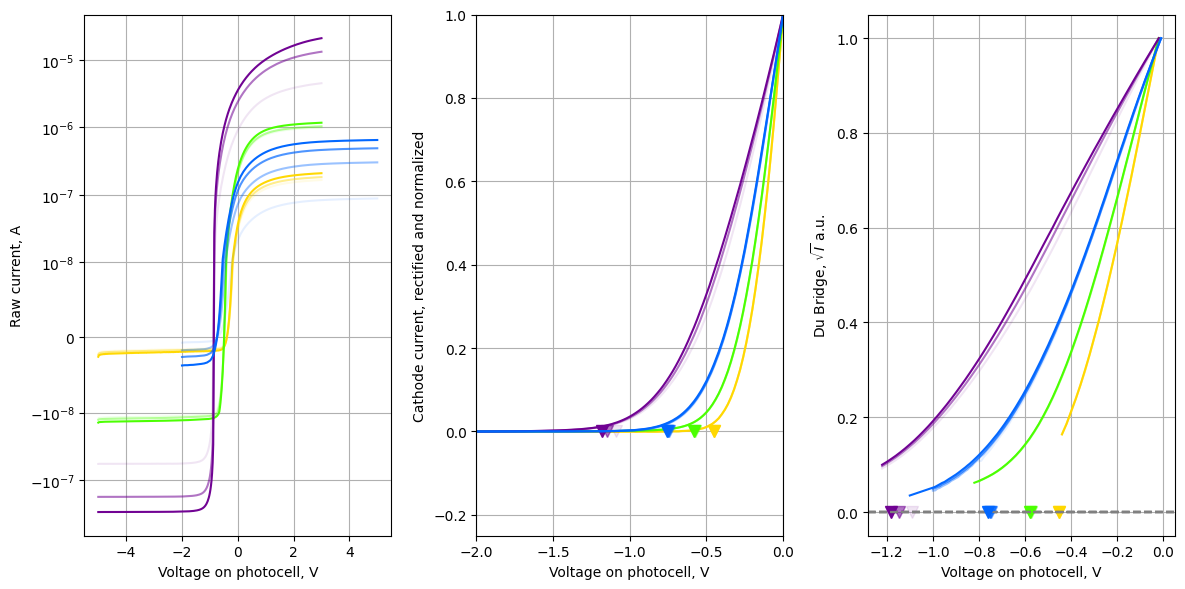

In [5]:
names = ['yellow_RCA929', 'green_RCA929', 'violet_RCA929', 'blue_RCA929']
waves = [592, 525, 397, 456]
n = len(names)


fig, ax = plt.subplots(1, 3, figsize=(12,6))
plt.grid()

data = '# color wavelength power V0 V0_err opacity\n'


for i, name in enumerate(names):
  color= wavelength_to_color(waves[i])
  url = URL+ f'{name}.csv'
  text = request.urlopen(url).read().decode('utf-8').splitlines()
  LED_V,V_set,V_actual,I_avg_A, I_std_A,  = np.genfromtxt(text, \
                              delimiter=',', usecols=[0,1,2,3,4], skip_header=1, unpack=True)

  powers = np.unique(LED_V)

  for power_index, power in enumerate(powers):


    V = V_set[LED_V==power]
    I = I_avg_A[LED_V==power]
    normalization_parameter = np.max(I[V <= NORMPOINT])
    if  np.max(powers) - np.min(powers) > 0:
      opacity = 0.1 + 0.89 * (power - np.min(powers)) / (np.max(powers) - np.min(powers))
    else:
      opacity = 1.0


    # (1) Raw VAC

    ax[0].plot(V, I, '-', ms=1, color=color, alpha=opacity)
    ax[0].set_xlabel('Voltage on photocell, V');
    ax[0].set_ylabel('Raw current, A')
    ax[0].set_yscale('symlog', linthresh=1e-8)
    ax[0].grid()

    # (2) остаток = катодный ток
    # Find points where current I crosses zero current line
    V0, d = find_root2(V, I,  return_diagnostics=True)
    if np.isnan(V0):
      print(name, d['reason'])
      continue
    # diagnostics
    R = d['cathode_current']
    on = d['cathode_mask']
    xv, yv = d['xv'], d['yv']
    cathode_fit = d['cathode_fit']
    # систематика от выбора окна (для погрешности в отчёте)
    v0_mean, v0_spread = v0_sensitivity(V, I)
    data += f'{i} {waves[i]} {power:.1f} {-v0_mean:.3f} {v0_spread:.3f} {opacity:.2f}#\n '
    normalization_parameter = np.max(R[V <= NORMPOINT])
    I /= normalization_parameter
    R /= normalization_parameter
    ax[1].plot(V, R, '-', ms=2, color=color, alpha=opacity)
    ax[1].plot(v0_mean, 0, 'v', ms=8, color=color, alpha=opacity)
    #ax[1].axvline(V0, color='#e08000', ls='--', label=f'V0 = {V0:.2f} В')
    ax[1].set_xlim(-2, 0.);
    ax[1].set_ylim(-0.25, 1)
    ax[1].set_xlabel('Voltage on photocell, V');
    ax[1].set_ylabel('Cathode current, rectified and normalized')
    ax[1].grid()

    # (3) Дю-Бридж: sqrt(R) vs V
    xv, yv = d['xv'], d['yv'];
    normalization_parameter = np.max(yv)
    yv /= normalization_parameter
    ax[2].axhline(0, color='gray', ls='--')
    ax[2].plot(v0_mean, 0, 'v', ms=8, color=color, alpha=opacity)
    ax[2].plot(xv, yv, '-', ms=2, color=color, alpha=opacity)
    ax[2].set_xlabel('Voltage on photocell, V');
    ax[2].set_ylabel('Du Bridge, $\sqrt{I}$ a.u.')
    #ax[2].grid()
plt.tight_layout()

print(data)

# Plank's constant and Work potential determination

$$
 e V_0(\nu) = h \nu -  e W
$$

/tmp/ipykernel_5396/3879080643.py:10: RuntimeWarning: divide by zero encountered in divide
  return c / wl


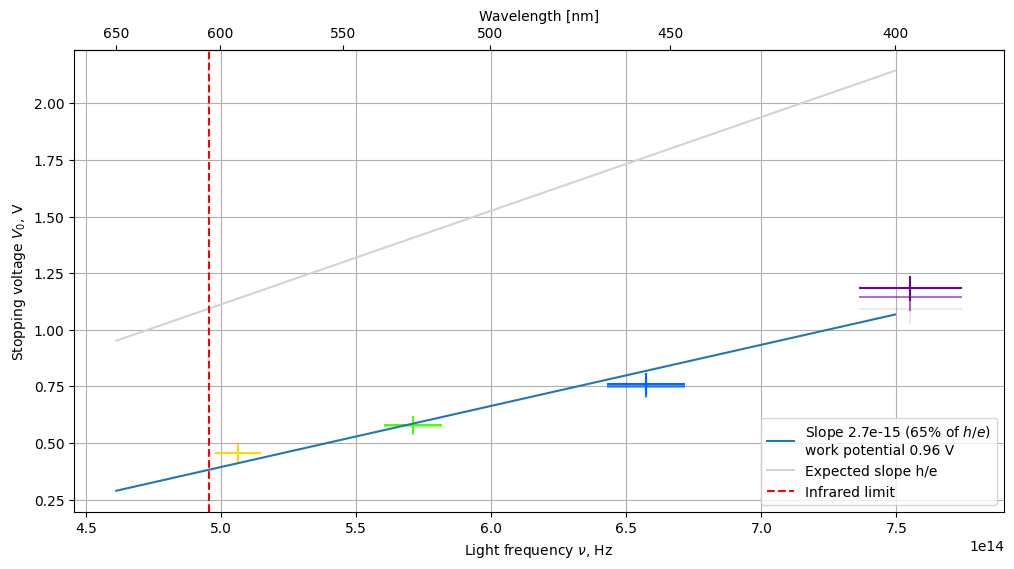

In [7]:
# S4 tubes work function
# source:
# "Phototubes and Photocells PT-10 1963" p.7 "Theory and Measurements "
offset_expected = 2.05 # eV, for S4  Photocathode

def linear(nu, slope, offset):
    return slope * nu - offset

def wl2freq(wl):
    return c / wl


def freq2wl(nu):
    return c / nu * 1e9

fig, ax = plt.subplots(figsize=(12,6))


secax = ax.secondary_xaxis('top', functions=(freq2wl, wl2freq))
secax.set_xlabel('Wavelength [nm]')


ix, wl, power, V0, V0_err, opacity = np.genfromtxt(data.splitlines()).T


relative_error = 10 / wl # error 10 nm

wl *= 1e-9
nu = c / wl
energy = h * nu / e # eV
nu_err = nu * relative_error
energy_err = energy * relative_error
# curve fit takes into account weights of uncertainties
# so it is more accurate than linregress calculates slope and offset
popt, pcov = curve_fit(linear, nu , V0)
slope = popt[0]
offset = popt[1]
err = np.sqrt(np.diag(pcov))
slope_err = err[0]
offset_err = err[1]



for i in range(len(V0)):
  ind = int(ix[i])
  plt.errorbar(nu[i], V0[i], yerr=V0_err[i], xerr=nu_err[i], ls='', color=wavelength_to_color(wl[i]*1e9), alpha=opacity[i])


wl_dense = np.linspace(400, 650)  * 1e-9
nu_dense = c / wl_dense

plt.plot(nu_dense, linear(nu_dense, slope, offset), label=f'Slope {slope:.1e} ({slope*e/h*100:.0f}% of $h/e$)\nwork potential {offset:.2f} V')
plt.plot(nu_dense, linear(nu_dense, h/e, offset) , color='lightgray', label=f'Expected slope h/e')

#for i in range(len(V0)):
#    plt.annotate(f'{wl[i]*1e9:.0f} nm', (V0[i], energy[i]))

plt.grid()
plt.legend()
plt.xlabel(r'Light frequency $\nu$, Hz')
plt.ylabel(r'Stopping voltage $V_0$, V')
Infrared_PhotoEmission_limit = offset_expected / h * e
plt.axvline(Infrared_PhotoEmission_limit, color='red', ls='--', label='Infrared limit')
plt.legend()
#plt.ylim(-0.25, 1.1)
plt.show()

